<a href="https://colab.research.google.com/github/kehkasha18/Projects/blob/main/GradientBoostingRegressor.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, r2_score



In [2]:
# Create synthetic data
np.random.seed(42)
X = np.random.randint(500, 4000, size=(200, 1))  # House size (sq ft)
y = X.flatten() * 50 + np.random.normal(0, 20000, 200)  # House price (target)

# Split into train and test sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [3]:
# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(n_estimators=100, learning_rate=0.1, max_depth=3, random_state=42)

# Train the model
gbr.fit(X_train, y_train)

# Make predictions
y_pred = gbr.predict(X_test)


In [4]:
# Calculate metrics
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse:.2f}")
print(f"R² Score: {r2:.2f}")


Mean Squared Error: 495217618.09
R² Score: 0.83


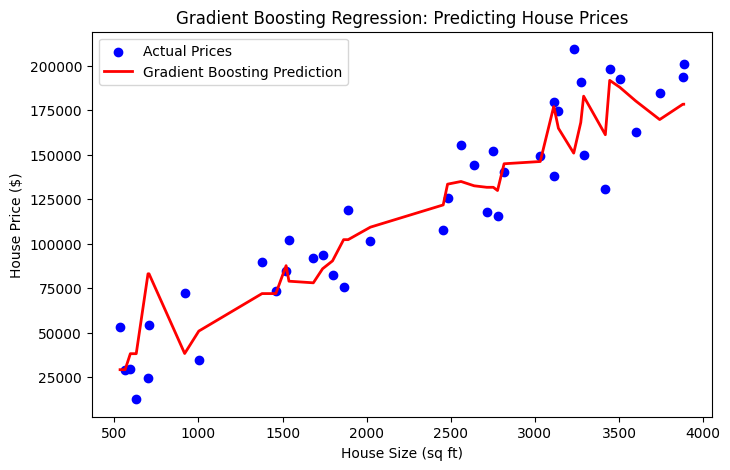

In [5]:
# Sort values for better visualization
X_test_sorted, y_pred_sorted = zip(*sorted(zip(X_test.flatten(), y_pred)))

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, color='blue', label='Actual Prices')
plt.plot(X_test_sorted, y_pred_sorted, color='red', linewidth=2, label='Gradient Boosting Prediction')
plt.xlabel("House Size (sq ft)")
plt.ylabel("House Price ($)")
plt.legend()
plt.title("Gradient Boosting Regression: Predicting House Prices")
plt.show()


## **Hyperparameter Tuning**

####**R² Score of 0.83** is already quite good, but we can improve it further by tuning hyperparameters using **Grid Search** or **Randomized Search**.
---

### **🎯 Key Hyperparameters to Tune**
1. **`n_estimators`**: Number of boosting stages (more = better learning, but slower training).
2. **`learning_rate`**: Controls the contribution of each tree (lower values need more trees).
3. **`max_depth`**: Maximum depth of each tree (higher values capture more complexity but risk overfitting).
4. **`min_samples_split`**: Minimum samples needed to split a node (prevents overfitting).
5. **`min_samples_leaf`**: Minimum samples in a leaf node (higher values = smoother models).
6. **`subsample`**: Fraction of samples used for fitting each tree (reduces overfitting).

---

### **🔍 Method 1: Grid Search (Systematic Search)**


In [6]:
from sklearn.model_selection import GridSearchCV

# Define parameter grid
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 3, 5],
    'subsample': [0.7, 0.8, 1.0]
}

# Initialize model
gbr = GradientBoostingRegressor(random_state=42)

# Perform Grid Search
grid_search = GridSearchCV(gbr, param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=1)
grid_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", grid_search.best_params_)

# Best model
best_gbr = grid_search.best_estimator_

# Predictions
y_pred_best = best_gbr.predict(X_test)

# Evaluate
mse_best = mean_squared_error(y_test, y_pred_best)
r2_best = r2_score(y_test, y_pred_best)

print(f"Optimized Mean Squared Error: {mse_best:.2f}")
print(f"Optimized R² Score: {r2_best:.2f}")


Fitting 5 folds for each of 729 candidates, totalling 3645 fits
Best Parameters: {'learning_rate': 0.05, 'max_depth': 3, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 100, 'subsample': 0.7}
Optimized Mean Squared Error: 371720657.11
Optimized R² Score: 0.88


### **🎲 Method 2: Randomized Search (Faster)**
Instead of testing all combinations, **RandomizedSearchCV** picks a subset randomly, making it faster.

In [7]:
from sklearn.model_selection import RandomizedSearchCV

# Define parameter distribution
param_dist = {
    'n_estimators': [100, 200, 300, 400, 500],
    'learning_rate': [0.01, 0.05, 0.1, 0.2],
    'max_depth': [3, 5, 7, 9],
    'min_samples_split': [2, 5, 10, 15],
    'min_samples_leaf': [1, 3, 5, 10],
    'subsample': [0.6, 0.7, 0.8, 1.0]
}

# Initialize model
gbr = GradientBoostingRegressor(random_state=42)

# Perform Randomized Search
random_search = RandomizedSearchCV(gbr, param_dist, n_iter=20, cv=5, scoring='r2', n_jobs=-1, random_state=42, verbose=1)
random_search.fit(X_train, y_train)

# Best parameters
print("Best Parameters:", random_search.best_params_)

# Best model
best_gbr_random = random_search.best_estimator_

# Predictions
y_pred_best_random = best_gbr_random.predict(X_test)

# Evaluate
mse_best_random = mean_squared_error(y_test, y_pred_best_random)
r2_best_random = r2_score(y_test, y_pred_best_random)

print(f"Optimized Mean Squared Error: {mse_best_random:.2f}")
print(f"Optimized R² Score: {r2_best_random:.2f}")


Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters: {'subsample': 0.6, 'n_estimators': 200, 'min_samples_split': 15, 'min_samples_leaf': 5, 'max_depth': 9, 'learning_rate': 0.01}
Optimized Mean Squared Error: 435794671.95
Optimized R² Score: 0.85


**Grid Search model performed better than the Randomized Search one:**

✅ **Grid Search Results**

* Optimized MSE: 371,720,657.11 (Lower is better)
* Optimized R² Score: 0.88 (Higher is better)

✅ **Randomized Search Results**

* Optimized MSE: 435,794,671.95
* Optimized R² Score: 0.85

In [17]:
best_gbr = GradientBoostingRegressor(
    learning_rate=0.01,
    max_depth=3,
    min_samples_leaf=5,
    min_samples_split=2,
    n_estimators=1000,  # Increased from 100 to 200
    subsample=0.7,
    random_state=42
)

best_gbr.fit(X_train, y_train)
y_pred_tuned = best_gbr.predict(X_test)

# Evaluate
mse_tuned = mean_squared_error(y_test, y_pred_tuned)
r2_tuned = r2_score(y_test, y_pred_tuned)

print(f"Tuned Mean Squared Error: {mse_tuned:.2f}")
print(f"Tuned R² Score: {r2_tuned:.2f}")


Tuned Mean Squared Error: 396198706.58
Tuned R² Score: 0.87


1️⃣ **Residual Plot (Check Errors)**

* A residual plot helps you see how well the model predictions match actual values. Ideally, residuals (errors) should be randomly scattered without patterns.

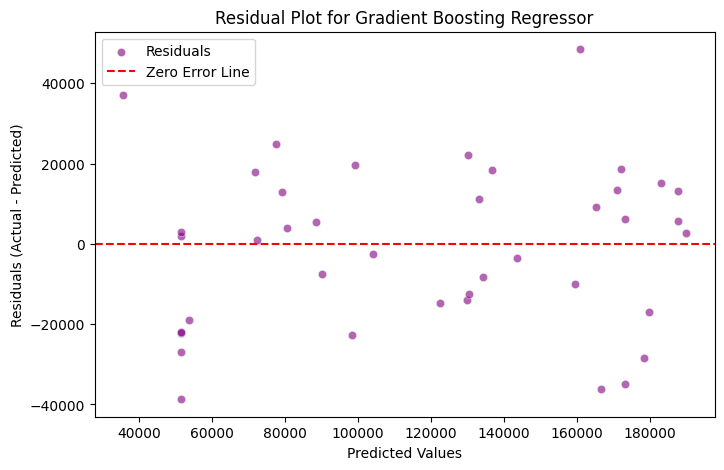

In [25]:
# Compute residuals
residuals = y_test - y_pred_tuned

plt.figure(figsize=(8, 5))
sns.scatterplot(x=y_pred_tuned, y=residuals, alpha=0.6, label="Residuals", color="purple")
plt.axhline(y=0, color='red', linestyle='--', label="Zero Error Line")  # Reference line for residuals

# Labels and title
plt.xlabel("Predicted Values")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residual Plot for Gradient Boosting Regressor")
plt.legend()  # Adding legend
plt.show()


2️⃣ **Predicted vs. Actual Plot**

* This scatterplot shows how well your predicted values match the actual values.

**What to look for?**

✅ Points close to the red line → Good predictions

❌ Scattered points far from line → Poor predictions



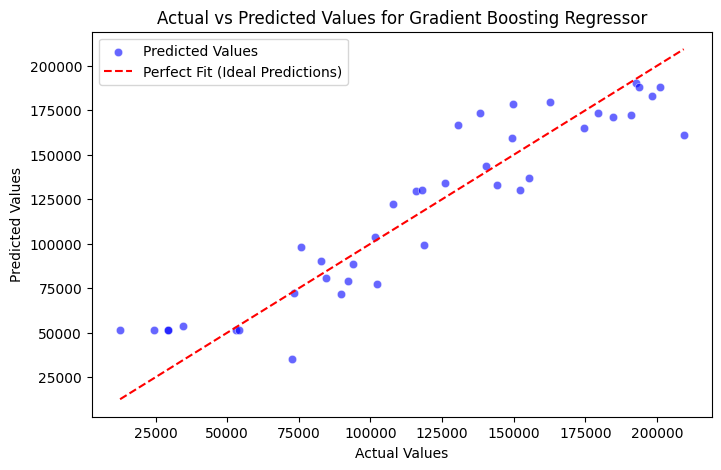

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))

# Scatter plot of actual vs. predicted values
sns.scatterplot(x=y_test, y=y_pred_tuned, alpha=0.6, label="Predicted Values", color="blue")

# Perfect prediction line (45-degree diagonal)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle="--", label="Perfect Fit (Ideal Predictions)")

# Labels and title
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Actual vs Predicted Values for Gradient Boosting Regressor")

# Add legend
plt.legend()

plt.show()



4️⃣ **Error Distribution Histogram**

**Check how prediction errors (residuals) are distributed.**

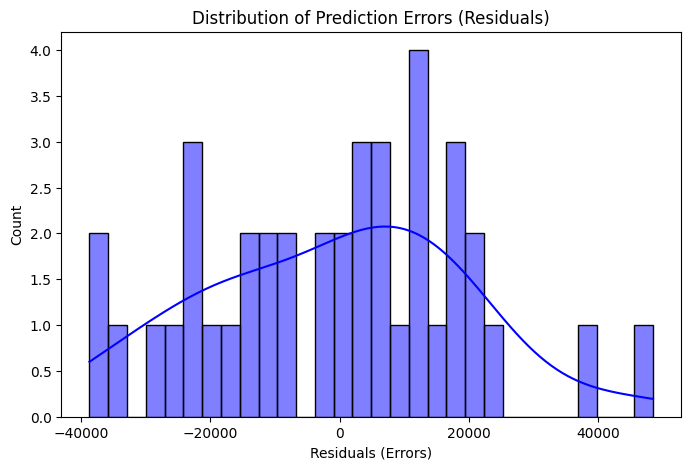

In [21]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True, bins=30, color="blue")
plt.xlabel("Residuals (Errors)")
plt.title("Distribution of Prediction Errors (Residuals)")
plt.show()


**What to look for?**

✅ Normal bell-shaped curve → Good model

❌ Skewed or multiple peaks → Potential bias in model